In [1]:
# Sel persiapan tambahan, bukan listing buku.
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Semua eksperimen memakai dataset kecil di notebook dan runtime CPU.')

Python: 3.13.16
NumPy: 2.1.3
Matplotlib: 3.10.0
Semua eksperimen memakai dataset kecil di notebook dan runtime CPU.


## 2. Ringkasan Chapter 6

Bab ini dimulai dengan masalah lampu lalu lintas. Setiap kondisi lampu disimpan sebagai baris matriks, sementara perilaku walk atau stop menjadi target. Model linear awal belajar satu observasi, kemudian memproses semua observasi berulang kali. Pembaruan per sampel memperkenalkan SGD, yang dibandingkan secara konseptual dengan pembaruan mini-batch dan full gradient descent.

Pada dataset pertama, target sama dengan nilai lampu tengah, sehingga bobot mendekati pola `[0, 1, 0]`. Buku menjelaskan pembelajaran melalui metafora tekanan naik dan turun pada bobot. Notebook melengkapi metafora itu dengan gradien yang sebenarnya: arah update ditentukan residual dan input, bukan sekadar hitungan tanda atau korelasi marginal. Satu observasi juga dapat dicocokkan oleh bobot yang gagal pada observasi lain, sehingga generalisasi menjadi perhatian penting.

Dataset kedua mengikuti XOR. Setiap input sendiri tidak cukup untuk memberikan hubungan linear yang dibutuhkan, tetapi kombinasi input menentukan target. Menumpuk lapisan linear saja tidak menambah kemampuan representasi karena perkalian matriks tersebut dapat digabung. ReLU memungkinkan hidden unit aktif hanya pada kondisi tertentu dan menghasilkan representasi nonlinear.

Backpropagation membawa sinyal turunan dari output ke hidden layer dengan aturan rantai. Setelah delta setiap lapisan diketahui, gradien bobot diperoleh dari activation input dan delta output. Notebook mereproduksi forward propagation, dua konvensi tanda delta, satu iterasi rinci, dan program lengkap 60 epoch. Hasil diperiksa dengan finite difference dan perbandingan model linear terbaik untuk XOR.

**Rujukan:** Trask (2019), hlm. 99-131.

## 3. Peta subbab dan cakupan notebook

| Subbab buku | Halaman cetak | Pengerjaan |
| --- | --- | --- |
| The streetlight problem | 100-101 | Dataset pertama dan arti feature/target |
| Preparing the data | 102 | Pemisahan masukan dan target |
| Matrices and the matrix relationship | 103-105 | Baris, kolom, skala, dan pengodean target |
| Creating a matrix or two in Python | 106 | Reproduksi matriks NumPy |
| Building a neural network | 107 | Satu sampel, 20 update, dan operasi elementwise |
| Learning the whole dataset | 108 | Seluruh enam sampel, 40 epoch |
| Full, batch, and stochastic gradient descent | 109 | Definisi dan eksperimen tambahan tiga ukuran batch |
| Neural networks learn correlation / Up and down pressure | 110-112 | Bobot akhir dan interpretasi gradien |
| Edge case: Overfitting | 113 | Fit satu observasi dan kegagalan pada observasi lain |
| Edge case: Conflicting pressure | 114-115 | Residual bersama, regularisasi, dan pengantar XOR |
| Learning indirect correlation / Creating correlation | 116-117 | Hidden representation |
| Stacking neural networks: A review | 118 | Dua matriks bobot dan forward propagation |
| Backpropagation: Long-distance error attribution / Why does this work? | 119-120 | Contoh delta dan aturan rantai |
| Linear vs. nonlinear | 121-122 | Kolaps lapisan linear dan keterbatasan XOR |
| The secret to sometimes correlation / A quick break | 123-124 | ReLU, mask turunan, dan penjelasan bersyarat |
| Your first deep neural network | 125 | Reproduksi forward dengan hidden size 4 |
| Backpropagation in code | 126-127 | Reproduksi delta target-minus-prediction dan update plus |
| One iteration of backpropagation | 128-129 | Hidden size 3, forward, delta, dan satu update |
| Putting it all together | 130 | Program lengkap 60 epoch, update minus |
| Why do deep networks matter? | 131 | Representasi bertingkat dan latihan mengingat kode |

Listing yang berulang pada diagram satu iterasi dibagi menurut tahapan dan dijalankan pada state yang sama. Contoh perbandingan batch, least squares, grafik, dan finite difference adalah tambahan. Tidak ada bobot atau output yang diisi seolah-olah merupakan hasil training tanpa eksekusi.

## 4. The streetlight problem: feature dan target

Dataset pertama mempunyai enam observasi dan tiga feature: lampu kiri, lampu tengah, serta lampu kanan. Nilai `1` berarti lampu menyala dan `0` berarti padam. Target `1` berarti WALK, sedangkan `0` berarti STOP.

| Observasi | Kiri | Tengah | Kanan | Target |
| --- | --- | --- | --- | --- |
| 1 | 1 | 0 | 1 | 0 / STOP |
| 2 | 0 | 1 | 1 | 1 / WALK |
| 3 | 0 | 0 | 1 | 0 / STOP |
| 4 | 1 | 1 | 1 | 1 / WALK |
| 5 | 0 | 1 | 1 | 1 / WALK |
| 6 | 1 | 0 | 1 | 0 / STOP |

Target sama dengan feature lampu tengah. Observasi kelima dan keenam mengulang pola sebelumnya; enam baris berarti enam observasi, tetapi hanya empat pola unik.

**Preparing the data:** masukan dan target dipisahkan sehingga model menerima keadaan lampu sebagai informasi dan menggunakan label walk/stop sebagai acuan pembelajaran. Contoh ini adalah data ilustratif dari buku, bukan aturan keselamatan lalu lintas yang divalidasi.

**Rujukan:** Trask (2019), hlm. 100-103.

## 5. Matrices and the matrix relationship

Matriks feature $X$ memiliki shape $(N,d)$: satu baris untuk satu observasi dan satu kolom untuk satu feature. Pada contoh pertama, shape adalah `(6, 3)`. Target dapat disimpan sebagai vektor `(6,)` atau matriks kolom `(6, 1)`, selama bentuk operasi konsisten.

Buku menunjukkan bahwa representasi intensitas dapat diskalakan, misalnya matriks $B=10A$ dan $C=2B$. Nilai numeriknya berbeda, tetapi transformasi skala yang diketahui mempertahankan hubungan yang dapat didekode. Skala tersebut tetap memengaruhi besar prediksi dan gradien: untuk mempertahankan prediksi linear setelah input dikalikan konstanta, bobot perlu disesuaikan secara berlawanan.

Pengodean target dapat dibalik jika pemetaan label juga dibalik. Label `[0, 1]` sendiri tidak mempunyai makna STOP/WALK tanpa definisi pemetaan. Istilah *lossless representation* di sini mengacu pada kemampuan mengembalikan kategori yang dikodekan, bukan menyimpan semua detail dunia nyata.

**Asal kode berikut:** nilai matriks intensitas A direproduksi dari diagram hlm. 104; B dan C dihitung sesuai hubungan skala hlm. 104-105. Perhitungan dan output eksplisit merupakan pendamping.

In [2]:
# Nilai matriks intensitas pada diagram hlm. 104, dengan perhitungan pendamping.
A = np.array([
    [0.9, 0.0, 1.0], [0.2, 0.8, 1.0], [0.1, 0.0, 1.0],
    [0.8, 0.9, 1.0], [0.1, 0.7, 1.0], [0.9, 0.1, 0.0],
])
B = A * 10
C = B * 2
print('Matriks A:')
print(A)
print('Matriks B = 10 * A:')
print(B)
print('Matriks C = 2 * B:')
print(C)
np.testing.assert_allclose(B / 10, A)
np.testing.assert_allclose(C / 20, A)
print('Hubungan skala dapat dibalik: LULUS')

Matriks A:
[[0.9 0.  1. ]
 [0.2 0.8 1. ]
 [0.1 0.  1. ]
 [0.8 0.9 1. ]
 [0.1 0.7 1. ]
 [0.9 0.1 0. ]]
Matriks B = 10 * A:
[[ 9.  0. 10.]
 [ 2.  8. 10.]
 [ 1.  0. 10.]
 [ 8.  9. 10.]
 [ 1.  7. 10.]
 [ 9.  1.  0.]]
Matriks C = 2 * B:
[[18.  0. 20.]
 [ 4. 16. 20.]
 [ 2.  0. 20.]
 [16. 18. 20.]
 [ 2. 14. 20.]
 [18.  2.  0.]]
Hubungan skala dapat dibalik: LULUS


## 6. Creating a matrix or two in Python

**Asal kode:** reproduksi hlm. 106. Masukan mempunyai shape `(6, 3)` dan target kolom `(6, 1)`. Bagian model linear selanjutnya mengikuti hlm. 107 dengan target satu dimensi `(6,)`.

**Shape perlu diperiksa:** prediksi `(6,)` dikurangi target `(6,1)` dapat menghasilkan matriks `(6,6)` melalui broadcasting. Hasil itu bukan enam residual yang dimaksud. Notebook memakai target satu dimensi untuk prediksi linear satu dimensi dan target kolom untuk keluaran jaringan yang dua dimensi.

NumPy menyediakan array numerik dengan shape dan operasi vektor/matriks; objek `np.array` di sini bukan list Python biasa. Struktur list of lists pada penulisan awal menjadi array dua dimensi.

In [3]:
# Reproduksi matriks hlm. 106.
streetlights = np.array([
    [1, 0, 1], [0, 1, 1], [0, 0, 1],
    [1, 1, 1], [0, 1, 1], [1, 0, 1],
])
walk_vs_stop = np.array([[0], [1], [0], [1], [1], [0]])

# Nama terpisah mempertahankan dataset pertama ketika dataset XOR diperkenalkan.
linear_inputs = streetlights.copy()
linear_targets_column = walk_vs_stop.copy()
linear_targets = walk_vs_stop.ravel()
print('Streetlights:')
print(streetlights)
print('Target kolom:')
print(walk_vs_stop)
print('Shape input / target:', streetlights.shape, walk_vs_stop.shape)
print('Target datar untuk model linear:', linear_targets)
print('Jumlah pola unik:', np.unique(streetlights, axis=0).shape[0])

Streetlights:
[[1 0 1]
 [0 1 1]
 [0 0 1]
 [1 1 1]
 [0 1 1]
 [1 0 1]]
Target kolom:
[[0]
 [1]
 [0]
 [1]
 [1]
 [0]]
Shape input / target: (6, 3) (6, 1)
Target datar untuk model linear: [0 1 0 1 1 0]
Jumlah pola unik: 4


## 7. Building a neural network: belajar satu pola

**Asal kode:** reproduksi hlm. 107. Bobot awal `[0.5, 0.48, -0.7]`, alpha `0.1`, dan 20 update hanya pada baris pertama `[1, 0, 1]` dengan target `0`.

Prediksi awal adalah `-0.2`; output linear dapat negatif. Residual digunakan untuk mengubah bobot kiri dan kanan. Bobot tengah tidak berubah karena input tengah pada sampel ini nol.

Algoritma mengikuti Chapter 5:

$$\hat y=\mathbf{x}^{T}\mathbf w,\quad
\delta=\hat y-y,\quad
\mathbf w\leftarrow\mathbf w-\alpha\delta\mathbf x$$

Gradien tersebut berasal dari $J=\tfrac12(\hat y-y)^2$, sementara `error` menampilkan squared error penuh. Nilai log dihitung sebelum update; sesudah loop, prediksi dihitung ulang dengan bobot akhir.

In [4]:
# Reproduksi hlm. 107; input -> input_data dan history ditambahkan.
weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1
streetlights = linear_inputs.copy()
walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])
input_data = streetlights[0]
goal_prediction = walk_vs_stop[0]
one_light_history = []

for iteration in range(20):
    prediction = input_data.dot(weights)
    error = (goal_prediction - prediction) ** 2
    delta = prediction - goal_prediction
    one_light_history.append({
        'iteration': iteration, 'weights': weights.copy(),
        'prediction': prediction, 'error': error,
    })
    weights = weights - alpha * (input_data * delta)
    print('Error:' + str(error) + ' Prediction:' + str(prediction))

one_light_final_weights = weights.copy()
print('Bobot setelah 20 update:', weights)
print('Prediksi setelah 20 update:', input_data.dot(weights))
print('Squared error setelah 20 update:', (input_data.dot(weights) - goal_prediction) ** 2)
print('Bobot tengah tetap:', weights[1])

Error:0.03999999999999998 Prediction:-0.19999999999999996
Error:0.025599999999999973 Prediction:-0.15999999999999992
Error:0.01638399999999997 Prediction:-0.1279999999999999
Error:0.010485759999999964 Prediction:-0.10239999999999982
Error:0.006710886399999962 Prediction:-0.08191999999999977
Error:0.004294967295999976 Prediction:-0.06553599999999982
Error:0.002748779069439994 Prediction:-0.05242879999999994
Error:0.0017592186044416036 Prediction:-0.04194304000000004
Error:0.0011258999068426293 Prediction:-0.03355443200000008
Error:0.0007205759403792803 Prediction:-0.02684354560000002
Error:0.0004611686018427356 Prediction:-0.021474836479999926
Error:0.0002951479051793508 Prediction:-0.01717986918399994
Error:0.00018889465931478573 Prediction:-0.013743895347199997
Error:0.00012089258196146188 Prediction:-0.010995116277759953
Error:7.737125245533561e-05 Prediction:-0.008796093022207963
Error:4.951760157141604e-05 Prediction:-0.007036874417766459
Error:3.169126500570676e-05 Prediction:-0.0

### Operasi elementwise NumPy

**Asal kode:** reproduksi contoh operasi hlm. 107. Perkalian `a * b` mengalikan elemen yang bersesuaian; `a.dot(b)` akan menjumlahkan kontribusi perkalian tersebut. Penambahan scalar seperti `a + 0.5` berlaku ke setiap elemen.

Perbedaan operasi ini menjelaskan mengapa `input_data * delta` menghasilkan vektor gradien, sedangkan `input_data.dot(weights)` menghasilkan satu prediksi.

In [5]:
# Reproduksi operasi NumPy hlm. 107.
a = np.array([0, 1, 2, 1])
b = np.array([2, 2, 2, 3])
print(a * b)
print(a + b)
print(a * 0.5)
print(a + 0.5)

[0 2 4 3]
[2 3 4 4]
[0.  0.5 1.  0.5]
[0.5 1.5 2.5 1.5]


## 8. Learning the whole dataset

**Asal kode:** reproduksi hlm. 108. Semua enam sampel diproses berurutan selama **40 epoch**, sehingga ada **240 update**. Satu epoch adalah satu kali melewati seluruh dataset.

Bobot diperbarui setelah setiap sampel. Prediksi sampel berikutnya menggunakan bobot yang sudah berubah. Pencetakan ditampilkan pada epoch 1, 2, 10, 20, 30, dan 40 agar output ringkas; seluruh perhitungan tetap dijalankan.

`error_for_all_lights` menjumlahkan error sebelum update pada setiap sampel dalam epoch. Karena bobot berubah di antara sampel, nilai itu adalah **jumlah error selama proses satu epoch**, bukan SSE pada satu bobot akhir yang tetap. Tambahan `fixed_sse` mengevaluasi seluruh dataset sesudah epoch dengan satu bobot yang sama.

SSE adalah jumlah squared error, sedangkan MSE adalah SSE dibagi jumlah observasi. Kedua nilai dibedakan pada evaluasi.

In [6]:
# Reproduksi hlm. 108; jumlah update dipertahankan, logging diringkas.
weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1
streetlights = linear_inputs.copy()
walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])
whole_linear_history = []

for iteration in range(40):
    error_for_all_lights = 0
    show_epoch = iteration in [0, 1, 9, 19, 29, 39]
    if show_epoch:
        print('Epoch:', iteration + 1)
    for row_index in range(len(walk_vs_stop)):
        input_data = streetlights[row_index]
        goal_prediction = walk_vs_stop[row_index]
        prediction = input_data.dot(weights)
        error = (goal_prediction - prediction) ** 2
        error_for_all_lights += error
        delta = prediction - goal_prediction
        weights = weights - alpha * (input_data * delta)
        if show_epoch:
            print('Prediction:' + str(prediction))
    fixed_predictions = streetlights.dot(weights)
    fixed_sse = np.sum((fixed_predictions - walk_vs_stop) ** 2)
    whole_linear_history.append({
        'epoch': iteration + 1, 'online_sse': error_for_all_lights,
        'fixed_sse': fixed_sse, 'weights': weights.copy(),
    })
    if show_epoch:
        print('Error:' + str(error_for_all_lights))
        print('SSE pada bobot akhir epoch:', fixed_sse)
        print()

whole_linear_final_weights = weights.copy()
whole_linear_predictions = linear_inputs @ weights
whole_linear_sse = np.sum((whole_linear_predictions - linear_targets) ** 2)
print('Bobot akhir:', whole_linear_final_weights)
print('Prediksi seluruh dataset:', whole_linear_predictions)
print('SSE akhir:', whole_linear_sse)
print('MSE akhir:', whole_linear_sse / len(linear_targets))

Epoch: 1
Prediction:-0.19999999999999996
Prediction:-0.19999999999999996
Prediction:-0.5599999999999999
Prediction:0.6160000000000001
Prediction:0.17279999999999995
Prediction:0.17552
Error:2.6561231104
SSE pada bobot akhir epoch: 1.14188095872

Epoch: 2
Prediction:0.14041599999999999
Prediction:0.3066464
Prediction:-0.34513824
Prediction:1.006637344
Prediction:0.4785034751999999
Prediction:0.26700416768
Error:0.9628701776715985
SSE pada bobot akhir epoch: 0.570132081384331

Epoch: 10
Prediction:0.04958243192113776
Prediction:0.9056327614440267
Prediction:-0.13768337501215525
Prediction:1.1250605910610996
Prediction:0.9132624284442169
Prediction:0.04653264583708144
Error:0.05564914990717743
SSE pada bobot akhir epoch: 0.04040250063358181

Epoch: 20
Prediction:-0.002013918045914484
Prediction:0.9832839794497644
Prediction:-0.06821774801198803
Prediction:1.0617271739912904
Prediction:0.9811035235627523
Prediction:-0.0035735447350425317
Error:0.009117233405426495
SSE pada bobot akhir epoc

## 9. Full, batch, dan stochastic gradient descent

| Metode | Sampel per update | Update per epoch pada enam sampel |
| --- | --- | --- |
| SGD / pembaruan per sampel | 1 | 6 |
| Mini-batch dengan ukuran 2 | 2 | 3 |
| Full gradient descent | 6 / seluruh dataset | 1 |

Buku menyebut pembaruan satu sampel sebagai SGD; listing memakai urutan data yang tetap. Dalam penggunaan umum, SGD sering melibatkan pengambilan sampel acak atau pengacakan urutan. Istilah **mini-batch** di notebook dipakai untuk metode yang disebut *batch gradient descent* dengan sebagian sampel pada hlm. 109, agar berbeda dari full-batch.

Untuk batch $B$ dengan $b$ observasi, gradien rata-rata half squared loss adalah:

$$J_B=\frac{1}{2b}\|X_B\mathbf w-\mathbf y_B\|^2,
\qquad\nabla J_B=\frac{1}{b}X_B^T(X_B\mathbf w-\mathbf y_B)$$

**Eksperimen berikut adalah tambahan**, bukan listing buku: ketiga metode memakai bobot awal, alpha, data, dan 40 epoch yang sama. Jumlah update berbeda, sehingga kecepatan pada grafik tidak menyatakan perbandingan biaya komputasi yang setara atau metode yang selalu paling cepat.

**Rujukan:** Trask (2019), hlm. 109.

In [7]:
# Perbandingan batch tambahan dengan evaluasi MSE memakai bobot tetap.
def train_linear_batches(X, y, batch_size, alpha=0.1, epochs=40):
    weights = np.array([0.5, 0.48, -0.7])
    update_count = 0
    history = [{
        'epoch': 0, 'mse': np.mean((X @ weights - y) ** 2),
        'weights': weights.copy(), 'updates': update_count,
    }]
    for epoch in range(1, epochs + 1):
        for start in range(0, len(X), batch_size):
            batch_X = X[start:start + batch_size]
            batch_y = y[start:start + batch_size]
            residual = batch_X @ weights - batch_y
            gradient = batch_X.T @ residual / len(batch_X)
            weights -= alpha * gradient
            update_count += 1
        history.append({
            'epoch': epoch, 'mse': np.mean((X @ weights - y) ** 2),
            'weights': weights.copy(), 'updates': update_count,
        })
    return history

batch_experiments = {
    size: train_linear_batches(linear_inputs, linear_targets, size)
    for size in [1, 2, 6]
}
print('Ukuran batch | Update setelah 40 epoch | MSE akhir | Bobot akhir')
for size, trace in batch_experiments.items():
    last = trace[-1]
    print(f"{size:12d} | {last['updates']:23d} | {last['mse']:.8f} | {last['weights']}")
np.testing.assert_allclose(batch_experiments[1][-1]['weights'], whole_linear_final_weights)
print('Pembaruan batch 1 setara dengan reproduksi hlm. 108: LULUS')

Ukuran batch | Update setelah 40 epoch | MSE akhir | Bobot akhir
           1 |                     240 | 0.00006855 | [ 0.01389228  1.0138147  -0.01599277]
           2 |                     120 | 0.00144209 | [ 0.0717363   1.05489062 -0.0709684 ]
           6 |                      40 | 0.01962464 | [ 0.28388217  1.02105522 -0.17151448]
Pembaruan batch 1 setara dengan reproduksi hlm. 108: LULUS


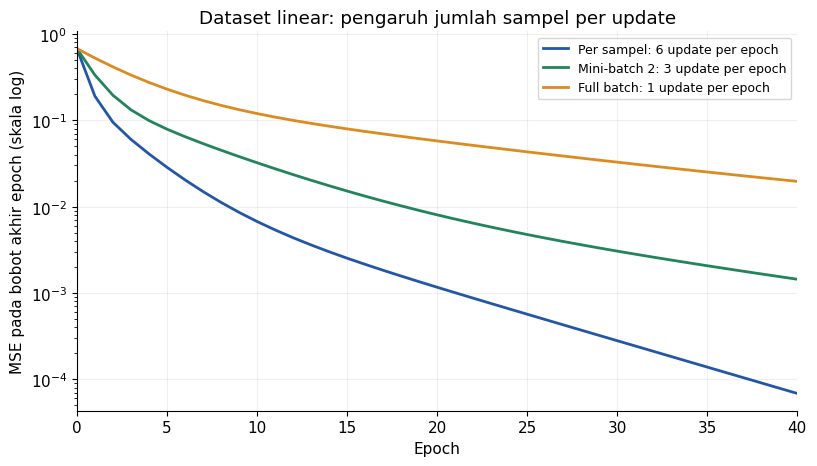

In [8]:
# Grafik tambahan: setiap titik MSE menggunakan satu bobot akhir epoch.
fig, ax = plt.subplots(figsize=(8.3, 4.8))
for size, label, color in [
    (1, 'Per sampel: 6 update per epoch', '#2456a6'),
    (2, 'Mini-batch 2: 3 update per epoch', '#21845b'),
    (6, 'Full batch: 1 update per epoch', '#db8b20'),
]:
    trace = batch_experiments[size]
    ax.semilogy([row['epoch'] for row in trace], [row['mse'] for row in trace],
                label=label, color=color, linewidth=2)
ax.set(title='Dataset linear: pengaruh jumlah sampel per update',
       xlabel='Epoch', ylabel='MSE pada bobot akhir epoch (skala log)', xlim=(0, 40))
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 10. Neural networks learn correlation: apa yang dipelajari?

Pada dataset pertama, target persis sama dengan lampu tengah. Bobot `[0, 1, 0]` menghasilkan prediksi yang tepat untuk semua baris. Training mendekati pola itu dengan mengurangi residual secara berulang.

Buku memakai kata *correlation* sebagai intuisi bahwa masukan yang membantu memprediksi target mendapat bobot yang sesuai. Secara matematis, algoritma mengoptimalkan loss, bukan menghitung korelasi Pearson dan menyalinnya menjadi bobot. Feature yang berkorelasi satu sama lain, perbedaan skala, dan kontribusi feature lain dapat memengaruhi nilai akhir bobot.

Lampu kanan selalu `1` pada dataset pertama. Ia bertindak seperti feature konstan atau intercept dalam model ini. Nilai bobot kanan dapat disesuaikan untuk menambahkan atau mengurangi offset. Tidak ada parameter bias yang ditulis terpisah.

**Asal kode berikut:** evaluasi tambahan dan solusi least squares untuk menunjukkan bahwa dataset pertama memang dapat dicocokkan model linear. Hasil ini juga menjadi pembanding terhadap dataset XOR nanti.

**Rujukan:** Trask (2019), hlm. 110-112.

In [9]:
# Pemeriksaan tambahan untuk hubungan target dengan feature tengah.
ideal_linear_weights = np.array([0.0, 1.0, 0.0])
least_squares_linear, _, _, _ = np.linalg.lstsq(linear_inputs, linear_targets, rcond=None)
print('Target sama dengan kolom tengah:', np.array_equal(linear_targets, linear_inputs[:, 1]))
print('Bobot hasil training:', whole_linear_final_weights)
print('Bobot least squares:', least_squares_linear)
print('Prediksi memakai bobot [0, 1, 0]:', linear_inputs @ ideal_linear_weights)
np.testing.assert_allclose(least_squares_linear, ideal_linear_weights, atol=1e-12)
print('Solusi linear tepat tersedia: LULUS')

Target sama dengan kolom tengah: True
Bobot hasil training: [ 0.01389228  1.0138147  -0.01599277]
Bobot least squares: [-0.  1. -0.]
Prediksi memakai bobot [0, 1, 0]: [0. 1. 0. 1. 1. 0.]
Solusi linear tepat tersedia: LULUS


## 11. Up and down pressure

Metafora tekanan pada hlm. 111-112 merangkum kecenderungan pembelajaran. Rumus update yang sebenarnya adalah:

$$\Delta w_i=-\alpha x_i(\hat y-y)$$

Input nol membuat update bobot itu nol. Untuk input positif, prediksi terlalu tinggi membuat bobot turun; prediksi terlalu rendah membuat bobot naik. Tanda ini ditentukan **residual saat ini**, sehingga tidak selalu dapat ditetapkan hanya dari label target.

**Ilustrasi tambahan berikut** menggunakan satu bobot tetap `[0.1, 0.2, 0.3]` untuk mengevaluasi tekanan setiap observasi. Ini bukan satu epoch SGD karena bobot tidak diperbarui di antara baris. Pada nilai tersebut, tanda update mirip tabel intuitif buku.

Sebagai contoh batas metafora, bobot awal listing hlm. 107 membuat prediksi pertama negatif. Target pertama nol, tetapi update bobot kiri dan kanan justru positif untuk menaikkan prediksi menuju nol. Karena itu, tanda minus pada tabel buku tidak berarti setiap sampel STOP selalu menurunkan setiap bobot.

**Rujukan:** Trask (2019), hlm. 111-112. Perhitungan tanda berdasarkan residual adalah pendalaman tambahan.

In [10]:
# Ilustrasi tambahan: tanda update dihitung dari residual pada bobot tetap.
pressure_weights = np.array([0.1, 0.2, 0.3])
print('Input | Target | Prediksi | Residual | Perubahan bobot jika alpha = 0.1')
for x_row, target in zip(linear_inputs, linear_targets):
    prediction = x_row @ pressure_weights
    residual = prediction - target
    update = -0.1 * residual * x_row
    print(f'{x_row} | {target:6d} | {prediction:8.3f} | {residual:8.3f} | {update}')

source_initial_weights = np.array([0.5, 0.48, -0.7])
first_residual = linear_inputs[0] @ source_initial_weights - linear_targets[0]
print('Residual pertama dengan bobot awal buku:', first_residual)
print('Update pertama dengan bobot awal buku:', -0.1 * first_residual * linear_inputs[0])

Input | Target | Prediksi | Residual | Perubahan bobot jika alpha = 0.1
[1 0 1] |      0 |    0.400 |    0.400 | [-0.04 -0.   -0.04]
[0 1 1] |      1 |    0.500 |   -0.500 | [0.   0.05 0.05]
[0 0 1] |      0 |    0.300 |    0.300 | [-0.   -0.   -0.03]
[1 1 1] |      1 |    0.600 |   -0.400 | [0.04 0.04 0.04]
[0 1 1] |      1 |    0.500 |   -0.500 | [0.   0.05 0.05]
[1 0 1] |      0 |    0.400 |    0.400 | [-0.04 -0.   -0.04]
Residual pertama dengan bobot awal buku: -0.19999999999999996
Update pertama dengan bobot awal buku: [0.02 0.   0.02]


## 12. Edge case: Overfitting

Model dapat cocok pada data yang sangat terbatas tetapi memberi prediksi buruk pada pola lain. Buku mencontohkan bobot kiri `0.5` dan kanan `-0.5`, yang saling meniadakan pada input pertama `[1, 0, 1]`.

Dengan bobot `[0.5, 0, -0.5]`, residual sampel pertama nol sehingga gradien dari sampel itu juga nol. Namun, observasi `[0, 1, 1]` diprediksi `-0.5` ketika targetnya `1`. Observasi lain memberikan sinyal gradien yang berbeda dan dapat mengubah bobot.

**Overfitting** secara umum adalah kegagalan generalisasi ketika model terlalu menyesuaikan data training. Fit satu sampel pada ilustrasi ini menunjukkan bagaimana konfigurasi bobot yang kebetulan cocok belum membuktikan bahwa hubungan yang dibutuhkan sudah dipelajari. Training lebih banyak sampel dapat membantu pada contoh ini, tetapi tidak otomatis menghilangkan overfitting pada semua masalah.

Data validation dan test yang terpisah diperlukan untuk menilai generalisasi pada tugas nyata. Notebook menggunakan data toy untuk memahami algoritma; ia tidak menyajikan evaluasi lapangan.

**Rujukan:** Trask (2019), hlm. 113.

In [11]:
# Ilustrasi numerik tambahan dari konfigurasi bobot yang dijelaskan hlm. 113.
accidental_fit_weights = np.array([0.5, 0.0, -0.5])
accidental_predictions = linear_inputs @ accidental_fit_weights
accidental_residuals = accidental_predictions - linear_targets
print('Bobot yang cocok pada sampel pertama:', accidental_fit_weights)
print('Prediksi semua sampel:', accidental_predictions)
print('Target:', linear_targets)
print('Squared error:', accidental_residuals ** 2)
print('Gradien sampel pertama:', accidental_residuals[0] * linear_inputs[0])
assert accidental_residuals[0] == 0
assert np.sum(accidental_residuals[1:] ** 2) > 0

Bobot yang cocok pada sampel pertama: [ 0.5  0.  -0.5]
Prediksi semua sampel: [ 0.  -0.5 -0.5  0.  -0.5  0. ]
Target: [0 1 0 1 1 0]
Squared error: [0.   2.25 0.25 1.   2.25 0.  ]
Gradien sampel pertama: [0. 0. 0.]


## 13. Edge case: Conflicting pressure dan regularisasi

Jumlah tanda positif dan negatif tidak cukup untuk menentukan gradien gabungan. Besar residual juga penting. Saat bobot tengah mulai menjelaskan target, residual yang perlu dikoreksi feature lain berubah karena semua bobot berbagi prediksi yang sama.

Misalkan bobot sudah `[0, 1, c]`. Karena lampu kanan selalu `1`, prediksi adalah target ditambah $c$. Residual seluruh sampel sama dengan $c$, sehingga gradien rata-rata terhadap bobot kanan adalah $c$. Alpha positif yang sesuai mendorong offset tersebut menuju nol, walaupun hitungan label WALK dan STOP sama banyak.

Buku mengenalkan regularisasi sebagai cara membatasi bobot yang menangkap pola yang kurang kuat. Sebagai pendalaman, L2 regularization pada model linear dapat ditulis:

$$J_{\mathrm{reg}}=\frac{1}{2N}\|X\mathbf w-\mathbf y\|^2
+\frac{\lambda}{2}\|\mathbf w\|^2$$

Gradien memperoleh tambahan $\lambda\mathbf w$, yang menarik bobot ke arah nol. Nilai lambda mengatur kompromi kecocokan data dan penalti. Regularisasi tidak selalu mempercepat training atau membuktikan bahwa feature berpengaruh kausal; rincian dan pemilihan regularisasi dibahas pada bab berikutnya.

**Asal kode berikut:** pemeriksaan tambahan untuk kasus offset $c=0.2$; bukan listing buku.

**Rujukan:** Trask (2019), hlm. 114-115.

In [12]:
# Pemeriksaan tambahan: feature konstan memperbaiki offset residual.
offset_weights = np.array([0.0, 1.0, 0.2])
offset_residual = linear_inputs @ offset_weights - linear_targets
offset_gradient = linear_inputs.T @ offset_residual / len(linear_inputs)
print('Residual ketika w = [0, 1, 0.2]:', offset_residual)
print('Gradien rata-rata:', offset_gradient)
print('Bobot kanan setelah satu full update alpha 0.1:', offset_weights[2] - 0.1 * offset_gradient[2])
np.testing.assert_allclose(offset_residual, 0.2)
np.testing.assert_allclose(offset_gradient[2], 0.2)

Residual ketika w = [0, 1, 0.2]: [0.2 0.2 0.2 0.2 0.2 0.2]
Gradien rata-rata: [0.1 0.1 0.2]
Bobot kanan setelah satu full update alpha 0.1: 0.18000000000000002


## 14. Dataset kedua: XOR dan learning indirect correlation

Pada hlm. 115-116, target diubah menjadi `1` jika lampu kiri dan tengah berbeda, serta `0` jika keduanya sama. Lampu kanan tetap `1`. Ini adalah pola **exclusive OR (XOR)**.

| Kiri | Tengah | Kanan | Target XOR |
| --- | --- | --- | --- |
| 1 | 0 | 1 | 1 |
| 0 | 1 | 1 | 1 |
| 0 | 0 | 1 | 0 |
| 1 | 1 | 1 | 0 |

Masing-masing feature kiri dan tengah secara sendiri mempunyai hubungan marginal yang seimbang dengan target, tetapi **kombinasi keduanya menentukan target sepenuhnya**. Jadi, ungkapan buku bahwa tidak ada korelasi tidak berarti data tidak mengandung hubungan. Hubungannya nonlinear. Feature kanan konstan, sehingga korelasi Pearson untuk kolom itu tidak terdefinisi akibat varians nol.

Model linear $\hat y=w_0x_0+w_1x_1+w_2$ tidak dapat menghasilkan empat target XOR secara tepat. Baris `[0,0,1]` menuntut $w_2=0$; dua baris dengan satu lampu aktif menuntut $w_0=w_1=1$; tetapi baris keduanya aktif kemudian menghasilkan `2`, bukan `0`.

**Creating correlation:** hidden layer membentuk feature baru dari kombinasi input, sehingga output dapat memakai representasi yang lebih sesuai. Pelatihan memilih bobot pembentuk representasi itu.

**Asal kode berikut:** nilai dataset direproduksi dari hlm. 115 dan listing hlm. 125. Least squares merupakan pembanding tambahan untuk menunjukkan batas model linear.

In [13]:
# Data XOR buku; pembanding least squares adalah tambahan.
xor_inputs = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1]])
xor_targets_column = np.array([[1, 1, 0, 0]]).T
xor_targets = xor_targets_column.ravel()
xor_linear_weights, _, _, _ = np.linalg.lstsq(xor_inputs, xor_targets, rcond=None)
xor_linear_predictions = xor_inputs @ xor_linear_weights
xor_linear_sse = np.sum((xor_linear_predictions - xor_targets) ** 2)
print('Input XOR:')
print(xor_inputs)
print('Target:', xor_targets)
print('Bobot linear least squares:', xor_linear_weights)
print('Prediksi linear terbaik:', xor_linear_predictions)
print('SSE linear minimum:', xor_linear_sse)
print('MSE linear minimum:', xor_linear_sse / len(xor_targets))
np.testing.assert_allclose(xor_linear_predictions, 0.5, atol=1e-12)
np.testing.assert_allclose(xor_linear_sse, 1.0, atol=1e-12)

Input XOR:
[[1 0 1]
 [0 1 1]
 [0 0 1]
 [1 1 1]]
Target: [1 1 0 0]
Bobot linear least squares: [-0.  -0.   0.5]
Prediksi linear terbaik: [0.5 0.5 0.5 0.5]
SSE linear minimum: 1.0
MSE linear minimum: 0.25


## 15. Stacking neural networks dan backpropagation

Jaringan mempunyai tiga lapisan: input `layer_0`, hidden `layer_1`, serta output `layer_2`. Dua matriks bobot menghubungkan lapisan tersebut. Output lapisan pertama menjadi input lapisan berikutnya.

**Backpropagation** menghitung turunan loss terhadap parameter dengan menerapkan aturan rantai dari output menuju lapisan sebelumnya. Ia menyediakan gradien; learning rate dan aturan update menggunakan gradien itu untuk mengubah bobot. Forward propagation menyimpan activation yang diperlukan pada tahap backward.

Ilustrasi hlm. 119-120 menggunakan delta output `+0.25` dan bobot hidden-ke-output `[0, 0.5, 1, -1]`. Mengalikan delta dengan bobot menghasilkan `[0, 0.125, 0.25, -0.25]`. Bobot nol tidak meneruskan sinyal delta melalui koneksi tersebut; bobot negatif membalik tandanya.

Buku menyebutnya *weighted average delta*. Operasi kode adalah **weighted sum / perkalian matriks**, tanpa pembagian untuk membuat rata-rata. Peran nonlinearity dan mask turunan ditambahkan pada bagian berikutnya.

**Asal kode berikut:** eksekusi tambahan angka ilustrasi diagram, bukan listing program training.

**Rujukan:** Trask (2019), hlm. 117-120. Konsep aturan rantai juga dibahas pada [catatan resmi Stanford CS231n](https://cs231n.github.io/optimization-2/).

In [14]:
# Eksekusi tambahan ilustrasi delta pada diagram hlm. 119-120.
diagram_output_delta = np.array([[0.25]])
diagram_hidden_output_weights = np.array([[0.0], [0.5], [1.0], [-1.0]])
diagram_hidden_delta = diagram_output_delta @ diagram_hidden_output_weights.T
print('Delta output:', diagram_output_delta)
print('Bobot hidden ke output:', diagram_hidden_output_weights.ravel())
print('Delta yang diteruskan ke hidden:', diagram_hidden_delta)
np.testing.assert_allclose(diagram_hidden_delta, [[0, 0.125, 0.25, -0.25]])

Delta output: [[0.25]]
Bobot hidden ke output: [ 0.   0.5  1.  -1. ]
Delta yang diteruskan ke hidden: [[ 0.     0.125  0.25  -0.25 ]]


## 16. Linear vs. nonlinear

Tanpa activation nonlinear, dua lapisan linear dapat digabung:

$$\hat{\mathbf y}=(\mathbf xW_{01})W_{12}
=\mathbf x(W_{01}W_{12})$$

Dengan $W_{\mathrm{efektif}}=W_{01}W_{12}$, fungsi akhirnya tetap satu transformasi linear. Jika kedua lapisan memakai bias, komposisinya tetap affine. Banyak parameter belum otomatis memberi kemampuan merepresentasikan XOR.

Hal ini adalah batas **representasi**, bukan pernyataan bahwa jaringan linear bertumpuk tidak dapat dilatih sama sekali. Ia dapat belajar hubungan yang sesuai dengan fungsi linear/affine, tetapi tidak dapat mencapai error nol untuk empat target XOR tersebut.

**Klarifikasi aritmetika hlm. 121:** persamaan cetak `1 * 10 * 2 = 100` seharusnya bernilai `20`. Prinsip yang dimaksud adalah dua perkalian dapat digabung, misalnya `1 * 0.25 * 0.9 = 1 * 0.225`.

**Asal kode berikut:** contoh matriks tambahan untuk memeriksa kesetaraan fungsi. Contoh perkalian scalar `0.25` dan `0.9` mengikuti ilustrasi buku.

**Rujukan:** Trask (2019), hlm. 121-122.

In [15]:
# Ilustrasi tambahan kolaps dua matriks linear.
linear_W01_demo = np.array([[0.5, 0.1], [0.2, 0.4], [-0.1, 0.3]])
linear_W12_demo = np.array([[1.0], [-0.5]])
stacked_linear_predictions = (xor_inputs @ linear_W01_demo) @ linear_W12_demo
collapsed_linear_predictions = xor_inputs @ (linear_W01_demo @ linear_W12_demo)
print('Dua lapisan linear:', stacked_linear_predictions.ravel())
print('Satu matriks efektif:', collapsed_linear_predictions.ravel())
print('Ilustrasi scalar:', 1 * 0.25 * 0.9, '=', 1 * (0.25 * 0.9))
print('Koreksi 1 * 10 * 2:', 1 * 10 * 2)
np.testing.assert_allclose(stacked_linear_predictions, collapsed_linear_predictions)
print('Komposisi linear setara: LULUS')

Dua lapisan linear: [ 0.2  -0.25 -0.25  0.2 ]
Satu matriks efektif: [ 0.2  -0.25 -0.25  0.2 ]
Ilustrasi scalar: 0.225 = 0.225
Koreksi 1 * 10 * 2: 20
Komposisi linear setara: LULUS


## 17. The secret to sometimes correlation: ReLU

Rectified Linear Unit (ReLU) mempertahankan nilai positif dan mengganti nilai negatif dengan nol:

$$\operatorname{ReLU}(z)=\max(0,z)$$

Activation ini membuat respons hidden unit bergantung pada kondisi input. Sebuah unit dapat aktif ketika kombinasi feature menghasilkan nilai positif, lalu tidak aktif ketika kombinasi lain menghasilkan nilai negatif.

Untuk $z>0$, turunan ReLU adalah `1`; untuk $z<0$, turunannya `0`. Pada $z=0$, turunan klasik tidak ada. Kode buku memilih nilai turunan `0` di titik tersebut melalui perbandingan `output > 0`.

`relu2deriv` menerima activation setelah ReLU. Memeriksa apakah activation positif menghasilkan mask yang dibutuhkan. Mask tersebut mengalikan delta hidden agar jalur yang tidak aktif tidak memperoleh gradien pada sampel itu.

**A quick break:** intuisi korelasi bersyarat membantu membaca buku, sedangkan aturan rantai, bentuk matriks, dan nilai residual menjadi dasar untuk memeriksa kode. ReLU merupakan salah satu activation nonlinear; pemilihan activation pada tugas lain memerlukan konteks model.

**Asal fungsi:** definisi `relu` dan `relu2deriv` direproduksi dari hlm. 125-126; nilai uji berikut adalah tambahan.

**Rujukan:** Trask (2019), hlm. 123-126.

In [16]:
# Fungsi buku; contoh nilai uji merupakan tambahan.
def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output > 0

relu_test_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print('Sebelum ReLU:', relu_test_values)
print('Sesudah ReLU:', relu(relu_test_values))
print('Mask turunan pada activation:', relu2deriv(relu(relu_test_values)).astype(int))

Sebelum ReLU: [-2.  -0.5  0.   0.5  2. ]
Sesudah ReLU: [-0.  -0.   0.   0.5  2. ]
Mask turunan pada activation: [0 0 0 1 1]


## 18. Representasi XOR dengan dua hidden unit

**Ilustrasi tambahan:** pilih $h_0=\operatorname{ReLU}(x_0-x_1)$ dan $h_1=\operatorname{ReLU}(x_1-x_0)$. Untuk input biner, $\hat y=h_0+h_1$ menghasilkan XOR tepat.

Unit pertama aktif hanya ketika kiri menyala dan tengah padam; unit kedua aktif pada keadaan sebaliknya. Saat keduanya sama, kedua activation nol. Ini memberi contoh konkret *sometimes correlation*: setiap hidden unit merespons konfigurasi tertentu.

Bobot ilustrasi berikut dipilih secara manual untuk membuktikan kemampuan representasi, bukan diklaim sebagai hasil training. Reproduksi jaringan yang benar-benar dilatih dari bobot acak diberikan selanjutnya.

**Rujukan konsep:** Trask (2019), hlm. 116-123.

In [17]:
# Konstruksi tambahan, dipilih manual untuk menunjukkan representasi XOR.
manual_W01 = np.array([[1.0, -1.0], [-1.0, 1.0], [0.0, 0.0]])
manual_W12 = np.array([[1.0], [1.0]])
manual_hidden = relu(xor_inputs @ manual_W01)
manual_predictions = manual_hidden @ manual_W12
print('Input | Hidden | Prediksi | Target')
for x_row, h_row, prediction, target in zip(
        xor_inputs, manual_hidden, manual_predictions.ravel(), xor_targets):
    print(f'{x_row} | {h_row} | {prediction:.1f} | {target}')
np.testing.assert_allclose(manual_predictions, xor_targets_column)
print('Representasi nonlinear menghasilkan XOR tepat: LULUS')

Input | Hidden | Prediksi | Target
[1 0 1] | [ 1. -0.] | 1.0 | 1
[0 1 1] | [-0.  1.] | 1.0 | 1
[0 0 1] | [0. 0.] | 0.0 | 0
[1 1 1] | [0. 0.] | 0.0 | 0
Representasi nonlinear menghasilkan XOR tepat: LULUS


## 19. Your first deep neural network: forward propagation

**Asal kode:** reproduksi hlm. 125. Seed `1`, alpha `0.2`, dan hidden size `4` dipertahankan. Bobot diinisialisasi dalam rentang `[-1, 1)` melalui `2 * np.random.random(...) - 1`.

Arsitektur mempunyai tiga input, empat hidden unit, dan satu output. Fungsi prediksinya:

$$\hat y=\operatorname{ReLU}(\mathbf xW_{01})W_{12}$$

Pada contoh forward ini, `streetlights[0]` adalah vektor satu dimensi. Listing training berikutnya memakai `streetlights[i:i+1]` agar tetap berbentuk matriks satu baris; perbedaan shape itu penting ketika memakai transpose untuk gradien.

Random initialization membedakan parameter antar hidden unit. Untuk ReLU dengan turunan nol pada activation nol, inisialisasi seluruh bobot nol dapat membuat seluruh gradien tetap nol. Seed dipertahankan agar reproduksi dapat dibandingkan, bukan untuk menjamin keberhasilan semua inisialisasi.

In [18]:
# Reproduksi hlm. 125.
np.random.seed(1)

def relu(x):
    return (x > 0) * x

alpha = 0.2
hidden_size = 4
streetlights = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1]])
walk_vs_stop = np.array([[1, 1, 0, 0]]).T
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

layer_0 = streetlights[0]
layer_1 = relu(np.dot(layer_0, weights_0_1))
layer_2 = np.dot(layer_1, weights_1_2)

# Penyimpanan dan output pendamping.
forward_initial_W01 = weights_0_1.copy()
forward_initial_W12 = weights_1_2.copy()
print('Shape W01 / W12:', weights_0_1.shape, weights_1_2.shape)
print('Layer 0:', layer_0)
print('Sebelum ReLU:', np.dot(layer_0, weights_0_1))
print('Layer 1:', layer_1)
print('Layer 2:', layer_2)
print('Shape tiap layer:', layer_0.shape, layer_1.shape, layer_2.shape)

Shape W01 / W12: (3, 4) (4, 1)
Layer 0: [1 0 1]
Sebelum ReLU: [-0.37242104  0.51828245 -1.16138222 -0.02489585]
Layer 1: [-0.          0.51828245 -0.         -0.        ]
Layer 2: [0.39194327]
Shape tiap layer: (3,) (4,) (1,)


## 20. Backpropagation: rumus, shape, dan urutan update

Bagian ini menuliskan **pendalaman matematis** dari listing hlm. 126-130. Pada training, masukan ditulis sebagai matriks baris. Untuk $B$ sampel, $d$ input, $H$ hidden unit, dan satu output:

| Besaran | Shape |
| --- | --- |
| $A_0$ / `layer_0` | $(B,d)$ |
| $W_{01}$ / `weights_0_1` | $(d,H)$ |
| $Z_1=A_0W_{01}$ | $(B,H)$ |
| $A_1=\operatorname{ReLU}(Z_1)$ | $(B,H)$ |
| $W_{12}$ / `weights_1_2` | $(H,1)$ |
| $\hat Y=A_1W_{12}$ dan target $Y$ | $(B,1)$ |

Orientasi matriks bab ini adalah **baris input, kolom output**, karena kode menggunakan `layer.dot(weights)`. Pada contoh list Chapter 5, matriks disusun dengan baris output. Orientasi yang dipilih menentukan posisi transpose dalam rumus gradien.

Untuk half sum squared error $J=\tfrac12\sum(\hat Y-Y)^2$:

$$
\begin{aligned}
\delta_2 &= \hat Y-Y,\\
\delta_1 &= (\delta_2W_{12}^{T})\odot\mathbf{1}[A_1>0],\\
G_{12} &= A_1^{T}\delta_2,\\
G_{01} &= A_0^{T}\delta_1.
\end{aligned}
$$

$\odot$ adalah perkalian elementwise. Delta output merupakan turunan terhadap keluaran linear; delta hidden setelah mask merupakan turunan terhadap nilai **sebelum ReLU**. Gradien setiap matriks mempunyai shape yang sama dengan matriks bobot tersebut.

Update memakai $W\leftarrow W-\alpha G$. Jika loss dirata-ratakan atas batch, kedua gradien juga dibagi $B$. Reproduksi buku memperbarui satu sampel setiap kali, sehingga $B=1$.

**Urutan penting:** delta hidden dihitung menggunakan `weights_1_2` dari forward pass yang sama, sebelum bobot itu diperbarui. Listing buku menghitung kedua delta terlebih dahulu. Menggunakan bobot output yang sudah berubah untuk menghitung delta hidden akan mengubah gradien langkah tersebut.

**Rujukan:** Trask (2019), hlm. 126-130; [catatan Stanford CS231n](https://cs231n.github.io/optimization-2/) sebagai referensi pendamping aturan rantai dan shape.

## 21. Dua konvensi tanda delta yang sama-sama benar

| Listing | Definisi delta output | Update |
| --- | --- | --- |
| Hlm. 126 | `target - prediction` | `weights += alpha * ...` |
| Hlm. 128-130 | `prediction - target` | `weights -= alpha * ...` |

Konvensi pertama adalah negatif dari turunan half squared loss, sehingga update menggunakan penambahan. Konvensi kedua langsung mengikuti tanda turunan, sehingga menggunakan pengurangan. Delta hidden juga mengikuti tanda delta output.

Kedua konvensi menghasilkan update yang sama jika tanda digunakan konsisten. Menggabungkan `target - prediction` dengan pengurangan gradien tanpa mengubah tanda dapat menggerakkan bobot ke arah yang salah.

**Asal kode berikut:** reproduksi hlm. 126-127, mempertahankan konvensi **target-minus-prediction dan update plus**. Data yang dirujuk dari hlm. 125 diinisialisasi kembali agar blok lengkap. Semua 60 epoch dan 240 update sampel dijalankan. Snapshot bobot dan evaluasi akhir epoch adalah tambahan untuk perbandingan.

In [19]:
# Reproduksi hlm. 126: delta target-minus-prediction, update plus.
np.random.seed(1)

def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output > 0

alpha = 0.2
hidden_size = 4
streetlights = xor_inputs.copy()
walk_vs_stop = xor_targets_column.copy()
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1
plus_history = []

for iteration in range(60):
    layer_2_error = 0
    for i in range(len(streetlights)):
        layer_0 = streetlights[i:i+1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)
        layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i+1]) ** 2)
        layer_2_delta = walk_vs_stop[i:i+1] - layer_2
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
        weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

    fixed_scores = relu(streetlights @ weights_0_1) @ weights_1_2
    plus_history.append({
        'epoch': iteration + 1, 'online_sse': layer_2_error,
        'fixed_sse': np.sum((fixed_scores - walk_vs_stop) ** 2),
    })
    if iteration % 10 == 9:
        print('Error:' + str(layer_2_error))

plus_final_W01 = weights_0_1.copy()
plus_final_W12 = weights_1_2.copy()
print('Konvensi plus selesai: 60 epoch, 240 update per sampel.')

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05
Konvensi plus selesai: 60 epoch, 240 update per sampel.


## 22. One iteration of backpropagation

### Langkah 1: inisialisasi hidden size 3

**Asal kode:** reproduksi hlm. 128. Ilustrasi satu iterasi memakai hidden size **3**, sedangkan program training sebelumnya dan program lengkap memakai **4**. Perbedaan ukuran ini dipertahankan.

Data `lights` dan target `walk_stop` adalah empat pola XOR. Seed diatur kembali agar bobot sesuai urutan random initialization untuk ukuran matriks ini.

In [20]:
# Reproduksi inisialisasi satu iterasi hlm. 128.
np.random.seed(1)

def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output > 0

lights = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1]])
walk_stop = np.array([[1, 1, 0, 0]]).T
alpha = 0.2
hidden_size = 3
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1
one_step_initial_W01 = weights_0_1.copy()
one_step_initial_W12 = weights_1_2.copy()
print('W01:')
print(weights_0_1)
print('W12:')
print(weights_1_2)

W01:
[[-0.16595599  0.44064899 -0.99977125]
 [-0.39533485 -0.70648822 -0.81532281]
 [-0.62747958 -0.30887855 -0.20646505]]
W12:
[[ 0.07763347]
 [-0.16161097]
 [ 0.370439  ]]


### Langkah 2: forward, compare, dan delta output

**Asal kode:** reproduksi langkah predict pada hlm. 128. Sel memakai baris pertama dan mempertahankan bentuk matriks `(1,3)`. Targetnya `1`, sehingga delta `prediction - target` bernilai negatif ketika prediksi masih di bawah target.

**Klarifikasi diagram:** dengan seed dan bobot tercetak, prediksi sekitar `-0.02130` sehingga delta output sekitar `-1.02130`. Label delta `0.14` pada diagram hlm. 128-129 tidak sesuai perhitungan tersebut. Notebook mengikuti kode serta targetnya, bukan label angka diagram.

In [21]:
# Reproduksi forward dan delta pada hlm. 128.
layer_0 = lights[0:1]
layer_1 = np.dot(layer_0, weights_0_1)
one_step_preactivation = layer_1.copy()
layer_1 = relu(layer_1)
layer_2 = np.dot(layer_1, weights_1_2)
error = (layer_2 - walk_stop[0:1]) ** 2
layer_2_delta = layer_2 - walk_stop[0:1]

one_step_layer_0 = layer_0.copy()
one_step_layer_1 = layer_1.copy()
one_step_layer_2 = layer_2.copy()
one_step_error_before = np.sum(error)
one_step_delta_2 = layer_2_delta.copy()
print('Layer 0:', layer_0)
print('Sebelum ReLU:', one_step_preactivation)
print('Layer 1:', layer_1)
print('Layer 2:', layer_2)
print('Squared error:', error)
print('Delta output:', layer_2_delta)

Layer 0: [[1 0 1]]
Sebelum ReLU: [[-0.79343557  0.13177044 -1.2062363 ]]
Layer 1: [[-0.          0.13177044 -0.        ]]
Layer 2: [[-0.02129555]]
Squared error: [[1.0430446]]
Delta output: [[-1.02129555]]


### Langkah 3: delta hidden layer

**Asal kode:** reproduksi langkah backpropagation hlm. 129. Forward yang sama pada diagram tidak diulang karena activation sudah tersedia dari sel sebelumnya dan bobot belum berubah.

Delta output dikalikan transpose bobot hidden-ke-output, lalu dikalikan mask ReLU secara elementwise. Pada contoh ini, hanya hidden unit kedua yang aktif. Delta tersebar sebelum mask dan delta setelah mask ditampilkan terpisah.

Karena delta output dan bobot menuju output dari unit aktif sama-sama negatif, hasil delta hidden pada unit itu **positif**, sekitar `0.16505`. Beberapa tanda pada diagram tidak sesuai hasil formula; kode menjadi acuan numeriknya.

In [22]:
# Reproduksi backpropagation hlm. 129; menggunakan forward pass sebelumnya.
layer_1_delta = layer_2_delta.dot(weights_1_2.T)
one_step_unmasked_delta = layer_1_delta.copy()
layer_1_delta *= relu2deriv(layer_1)
one_step_delta_1 = layer_1_delta.copy()
print('Delta hidden sebelum mask:', one_step_unmasked_delta)
print('Mask ReLU:', relu2deriv(layer_1).astype(int))
print('Delta hidden setelah mask:', layer_1_delta)

Delta hidden sebelum mask: [[-0.07928672  0.16505257 -0.3783277 ]]
Mask ReLU: [[0 1 0]]
Delta hidden setelah mask: [[-0.          0.16505257 -0.        ]]


### Langkah 4: gradien matriks dan pembaruan

**Asal kode:** reproduksi langkah update hlm. 129. Activation input ditranspose agar perkalian matriks menghasilkan shape yang sama dengan bobot. Kedua gradien dihitung dari forward/delta yang sama sebelum update.

Baris kedua pada gradien input-ke-hidden nol karena feature tengah untuk sampel ini bernilai nol. Kolom hidden yang tidak aktif juga mempunyai gradien nol. Evaluasi setelah update merupakan tambahan untuk melihat perubahan loss.

In [23]:
# Reproduksi gradien dan update hlm. 129.
weight_delta_1_2 = layer_1.T.dot(layer_2_delta)
weight_delta_0_1 = layer_0.T.dot(layer_1_delta)
one_step_G12 = weight_delta_1_2.copy()
one_step_G01 = weight_delta_0_1.copy()
weights_1_2 -= alpha * weight_delta_1_2
weights_0_1 -= alpha * weight_delta_0_1
one_step_final_W01 = weights_0_1.copy()
one_step_final_W12 = weights_1_2.copy()
one_step_prediction_after = relu(one_step_layer_0 @ weights_0_1) @ weights_1_2
one_step_error_after = np.sum((one_step_prediction_after - walk_stop[0:1]) ** 2)
print('Gradien W12:')
print(weight_delta_1_2)
print('Gradien W01:')
print(weight_delta_0_1)
print('Shape gradien:', weight_delta_0_1.shape, weight_delta_1_2.shape)
print('Prediksi setelah update:', one_step_prediction_after)
print('SSE sebelum / sesudah:', one_step_error_before, '/', one_step_error_after)

Gradien W12:
[[ 0.        ]
 [-0.13457656]
 [ 0.        ]]
Gradien W01:
[[0.         0.16505257 0.        ]
 [0.         0.         0.        ]
 [0.         0.16505257 0.        ]]
Shape gradien: (3, 3) (3, 1)
Prediksi setelah update: [[-0.00885616]]
SSE sebelum / sesudah: 1.0430445982842722 / 1.017790752978781


## 23. Putting it all together: program lengkap

**Asal kode:** reproduksi program mandiri hlm. 130. Data, seed `1`, hidden size `4`, alpha `0.2`, serta 60 epoch dipertahankan. Konvensi delta sekarang `prediction - target` dengan update **minus**.

Enam baris `Error:` dicetak setiap sepuluh epoch sesuai buku. Tambahan history menyimpan SSE pada bobot akhir setiap epoch. Pencatatan tersebut tidak mengubah update. Program memproses empat sampel setiap epoch, sehingga terdapat 240 langkah SGD.

Nilai target dan urutan baris identik dengan reproduksi konvensi plus. Kedua hasil akhir akan dibandingkan. Nilai loss dapat sangat kecil tanpa harus nol persis setelah 60 epoch.

In [24]:
# Reproduksi program lengkap hlm. 130: delta prediction-minus-target, update minus.
np.random.seed(1)

def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output > 0

streetlights = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1]])
walk_vs_stop = np.array([[1, 1, 0, 0]]).T
alpha = 0.2
hidden_size = 4
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1
deep_initial_W01 = weights_0_1.copy()
deep_initial_W12 = weights_1_2.copy()
initial_deep_scores = relu(streetlights @ weights_0_1) @ weights_1_2
initial_deep_sse = np.sum((initial_deep_scores - walk_vs_stop) ** 2)
deep_history = []

for iteration in range(60):
    layer_2_error = 0
    for i in range(len(streetlights)):
        layer_0 = streetlights[i:i+1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)
        layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i+1]) ** 2)
        layer_2_delta = layer_2 - walk_vs_stop[i:i+1]
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

    fixed_scores = relu(streetlights @ weights_0_1) @ weights_1_2
    deep_history.append({
        'epoch': iteration + 1, 'online_sse': layer_2_error,
        'fixed_sse': np.sum((fixed_scores - walk_vs_stop) ** 2),
    })
    if iteration % 10 == 9:
        print('Error:' + str(layer_2_error))

deep_final_W01 = weights_0_1.copy()
deep_final_W12 = weights_1_2.copy()
deep_final_hidden = relu(xor_inputs @ deep_final_W01)
deep_final_scores = deep_final_hidden @ deep_final_W12
deep_final_sse = np.sum((deep_final_scores - xor_targets_column) ** 2)
print('SSE pada satu bobot akhir yang tetap:', deep_final_sse)
print('MSE pada satu bobot akhir yang tetap:', deep_final_sse / len(xor_inputs))

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05
SSE pada satu bobot akhir yang tetap: 9.017549421055648e-06
MSE pada satu bobot akhir yang tetap: 2.254387355263912e-06


## 24. Evaluasi hasil XOR dan representasi hidden

**Asal kode dan grafik:** evaluasi tambahan atas model yang dilatih pada hlm. 130. Semua pola dievaluasi dengan satu bobot akhir yang sama. Threshold `0.5` dipakai sebagai aturan keputusan untuk label biner ilustrasi ini.

Output model tetap **skor linear**, bukan probabilitas yang dijamin berada dalam rentang `[0,1]`. Pemilihan threshold tidak mengubah fungsi loss training. Hasil klasifikasi pada empat pola training belum menilai generalisasi pada data lain.

Model linear terbaik mempunyai SSE `1` pada dataset XOR, sedangkan jaringan ReLU dapat menurunkannya jauh di bawah nilai itu. Grafik membandingkan **SSE pada bobot tetap sesudah setiap epoch**, bukan mencampurkan jumlah error online buku dengan SSE evaluasi.

Heatmap memperlihatkan activation empat hidden unit untuk setiap pola. Pada seed ini, beberapa unit tidak aktif; unit yang aktif membentuk representasi bersyarat yang membantu output membedakan target. Jika unit ReLU tidak aktif pada semua sampel dan seluruh gradien masuknya nol, ia dapat tetap tidak aktif dalam training ini.

In [25]:
# Evaluasi tambahan: skor, keputusan kelas, dan kesetaraan tanda delta.
deep_predicted_classes = (deep_final_scores.ravel() >= 0.5).astype(int)
print('Pola | Target | Skor akhir | Kelas dengan threshold 0.5')
for x_row, target, score, predicted_class in zip(
        xor_inputs, xor_targets, deep_final_scores.ravel(), deep_predicted_classes):
    print(f'{x_row} | {target:6d} | {score:10.7f} | {predicted_class}')
print('Activation hidden setelah training:')
print(deep_final_hidden)
print('SSE linear terbaik:', xor_linear_sse)
print('SSE jaringan ReLU:', deep_final_sse)
print('Kecocokan kelas pada empat pola training:', np.mean(deep_predicted_classes == xor_targets))

np.testing.assert_allclose(plus_final_W01, deep_final_W01, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(plus_final_W12, deep_final_W12, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(
    [row['online_sse'] for row in plus_history],
    [row['online_sse'] for row in deep_history], rtol=1e-12, atol=1e-12)
print('Dua konvensi tanda menghasilkan bobot dan trajectory error yang sama: LULUS')

Pola | Target | Skor akhir | Kelas dengan threshold 0.5
[1 0 1] |      1 |  1.0000000 | 1
[0 1 1] |      1 |  0.9985533 | 1
[0 0 1] |      0 |  0.0026314 | 0
[1 1 1] |      0 |  0.0000000 | 0
Activation hidden setelah training:
[[-0.          0.87748444 -0.         -0.        ]
 [-0.         -0.         -0.          0.89940474]
 [-0.         -0.         -0.          0.00237016]
 [-0.         -0.         -0.         -0.        ]]
SSE linear terbaik: 1.0
SSE jaringan ReLU: 9.017549421055648e-06
Kecocokan kelas pada empat pola training: 1.0
Dua konvensi tanda menghasilkan bobot dan trajectory error yang sama: LULUS


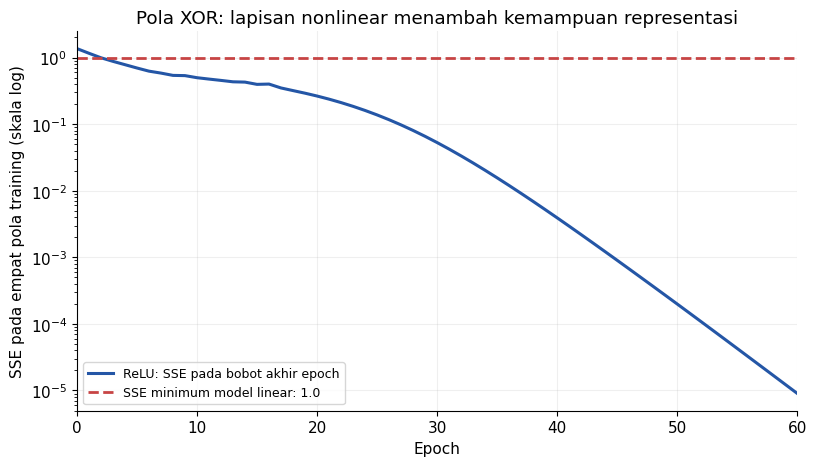

In [26]:
# Grafik tambahan: batas representasi linear dibanding hasil training ReLU.
epochs = [0] + [row['epoch'] for row in deep_history]
fixed_deep_losses = [initial_deep_sse] + [row['fixed_sse'] for row in deep_history]
fig, ax = plt.subplots(figsize=(8.3, 4.8))
ax.semilogy(epochs, fixed_deep_losses, color='#2456a6', linewidth=2.2,
            label='ReLU: SSE pada bobot akhir epoch')
ax.axhline(xor_linear_sse, color='#c74444', linestyle='--', linewidth=2,
           label='SSE minimum model linear: 1.0')
ax.set(title='Pola XOR: lapisan nonlinear menambah kemampuan representasi',
       xlabel='Epoch', ylabel='SSE pada empat pola training (skala log)', xlim=(0, 60))
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

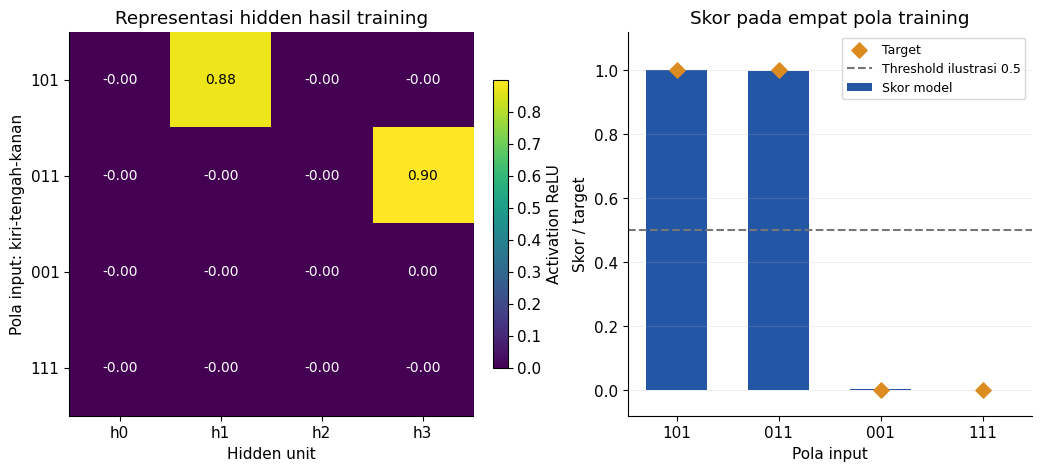

In [27]:
# Grafik tambahan: activation hidden dan skor akhir pada pola XOR.
input_labels = ['101', '011', '001', '111']
fig, axes = plt.subplots(1, 2, figsize=(10.3, 4.6), layout='constrained')
im = axes[0].imshow(deep_final_hidden, cmap='viridis', interpolation='nearest', aspect='auto')
axes[0].set_xticks(np.arange(4), labels=['h0', 'h1', 'h2', 'h3'])
axes[0].set_yticks(np.arange(4), labels=input_labels)
axes[0].set(title='Representasi hidden hasil training', xlabel='Hidden unit',
            ylabel='Pola input: kiri-tengah-kanan')
max_activation = np.max(deep_final_hidden)
for row_index in range(4):
    for column_index in range(4):
        value = deep_final_hidden[row_index, column_index]
        color = 'white' if value < 0.55 * max_activation else 'black'
        axes[0].text(column_index, row_index, f'{value:.2f}',
                     ha='center', va='center', color=color, fontsize=10)
fig.colorbar(im, ax=axes[0], shrink=0.75, label='Activation ReLU')
positions = np.arange(4)
axes[1].bar(positions, deep_final_scores.ravel(), color='#2456a6', width=0.6, label='Skor model')
axes[1].scatter(positions, xor_targets, color='#db8b20', marker='D', s=60,
                label='Target', zorder=4)
axes[1].axhline(0.5, color='#777777', linestyle='--', label='Threshold ilustrasi 0.5')
axes[1].set_xticks(positions, labels=input_labels)
axes[1].set(title='Skor pada empat pola training', xlabel='Pola input',
            ylabel='Skor / target', ylim=(-0.08, 1.12))
axes[1].grid(axis='y', alpha=0.2)
axes[1].legend(fontsize=9, loc='upper right')
plt.show()

## 25. Pemeriksaan gradien backpropagation dengan finite difference

**Pendalaman tambahan:** turunan kedua matriks bobot diperiksa melalui perubahan kecil pada setiap parameter. Fungsi loss untuk pemeriksaan memakai half **mean** squared error atas empat observasi:

$$J=\frac{1}{2N}\sum_{i=1}^{N}(\hat y_i-y_i)^2$$

Karena dirata-ratakan, gradien analitis dibagi $N$. Ini adalah pemeriksaan full dataset, sedangkan kode reproduksi menggunakan update per sampel. Rumus lokal backpropagationnya sama.

Central finite difference untuk parameter $w$ adalah:

$$\frac{\partial J}{\partial w}\approx
\frac{J(w+\varepsilon)-J(w-\varepsilon)}{2\varepsilon}$$

Pemeriksaan dilakukan pada bobot awal hidden size 4. Nilai sebelum ReLU diperiksa agar tidak berada di titik nol atau terlalu dekat dengannya; di titik pergantian ReLU, pendekatan numerik dapat berbeda dari pilihan turunan yang dipakai kode.

Memeriksa semua 16 parameter membantu menemukan kesalahan tanda, transpose, faktor rata-rata, atau mask. Ini bukan pengganti teori, tetapi pemeriksaan independen terhadap turunan yang diturunkan.

In [28]:
# Pemeriksaan tambahan: turunan analitis versus finite difference untuk 16 parameter.
def deep_half_mean_loss_and_gradients(X, Y, W01, W12):
    preactivation = X @ W01
    hidden = relu(preactivation)
    prediction = hidden @ W12
    residual = prediction - Y
    loss = 0.5 * np.sum(residual ** 2) / len(X)
    delta_2 = residual / len(X)
    delta_1 = (delta_2 @ W12.T) * relu2deriv(hidden)
    gradient_12 = hidden.T @ delta_2
    gradient_01 = X.T @ delta_1
    return loss, gradient_01, gradient_12

check_W01 = deep_initial_W01.copy()
check_W12 = deep_initial_W12.copy()
min_relu_distance = np.min(np.abs(xor_inputs @ check_W01))
epsilon_fd = 1e-6
assert min_relu_distance > 100 * epsilon_fd
check_loss, check_G01, check_G12 = deep_half_mean_loss_and_gradients(
    xor_inputs, xor_targets_column, check_W01, check_W12)
numerical_gradients = []
print('Loss half mean squared error:', check_loss)
print('Jarak terkecil preactivation dari nol:', min_relu_distance)

for parameter_name, original, analytic_gradient in [
    ('W01', check_W01, check_G01), ('W12', check_W12, check_G12),
]:
    numerical = np.zeros_like(original)
    for index in np.ndindex(original.shape):
        parameter_plus = original.copy()
        parameter_minus = original.copy()
        parameter_plus[index] += epsilon_fd
        parameter_minus[index] -= epsilon_fd
        if parameter_name == 'W01':
            loss_plus = deep_half_mean_loss_and_gradients(
                xor_inputs, xor_targets_column, parameter_plus, check_W12)[0]
            loss_minus = deep_half_mean_loss_and_gradients(
                xor_inputs, xor_targets_column, parameter_minus, check_W12)[0]
        else:
            loss_plus = deep_half_mean_loss_and_gradients(
                xor_inputs, xor_targets_column, check_W01, parameter_plus)[0]
            loss_minus = deep_half_mean_loss_and_gradients(
                xor_inputs, xor_targets_column, check_W01, parameter_minus)[0]
        numerical[index] = (loss_plus - loss_minus) / (2 * epsilon_fd)
    np.testing.assert_allclose(numerical, analytic_gradient, rtol=1e-6, atol=1e-8)
    numerical_gradients.append(numerical)
    max_error = np.max(np.abs(numerical - analytic_gradient))
    print(f'{parameter_name}: shape {original.shape}, selisih terbesar {max_error:.3e}: LULUS')
print('Seluruh 12 + 4 parameter sesuai finite difference.')

Loss half mean squared error: 0.1703030031468611
Jarak terkecil preactivation dari nol: 0.02489585394280147
W01: shape (3, 4), selisih terbesar 1.267e-11: LULUS
W12: shape (4, 1), selisih terbesar 1.181e-11: LULUS
Seluruh 12 + 4 parameter sesuai finite difference.


## 26. Verifikasi hasil reproduksi

Sel berikut memeriksa jumlah langkah, hasil dasar, konvensi tanda, masking ReLU, serta enam nilai error program lengkap terhadap angka cetak buku. Perbandingan memakai toleransi karena angka pada buku dibulatkan dan floating point dapat menampilkan digit tambahan.

SSE pada log terakhir tidak dipaksa sama dengan SSE setelah update terakhir. Kedua nilai memang diukur dengan cara berbeda sebagaimana dijelaskan pada bagian 8.

In [29]:
# Pemeriksaan tambahan atas hasil utama bab.
assert linear_inputs.shape == (6, 3)
assert linear_targets_column.shape == (6, 1)
assert len(one_light_history) == 20
assert len(whole_linear_history) == 40
assert one_light_final_weights[1] == 0.48
np.testing.assert_allclose(one_light_history[0]['prediction'], -0.2)
np.testing.assert_allclose(one_light_history[0]['error'], 0.04)
np.testing.assert_allclose(whole_linear_history[0]['online_sse'], 2.6561231104)
np.testing.assert_allclose(whole_linear_history[-1]['online_sse'], 0.000533736773285,
                           rtol=1e-9, atol=1e-12)
assert whole_linear_history[-1]['fixed_sse'] < whole_linear_history[0]['fixed_sse']
assert batch_experiments[1][-1]['updates'] == 240
assert batch_experiments[2][-1]['updates'] == 120
assert batch_experiments[6][-1]['updates'] == 40

np.testing.assert_allclose(manual_predictions, xor_targets_column)
np.testing.assert_allclose(one_step_delta_2, one_step_layer_2 - 1)
assert one_step_delta_2.item() < 0
assert one_step_delta_1[0, 1] > 0
np.testing.assert_allclose(one_step_delta_1[one_step_layer_1 == 0], 0)
np.testing.assert_allclose(one_step_G01[1], 0)  # Feature tengah nol untuk sampel pertama.
assert one_step_G01.shape == one_step_initial_W01.shape == (3, 3)
assert one_step_G12.shape == one_step_initial_W12.shape == (3, 1)
assert one_step_error_after < one_step_error_before

expected_book_errors = np.array([
    0.634231159844, 0.358384076763, 0.0830183113303,
    0.0064670549571, 0.000329266900075, 1.50556226651e-5,
])
actual_book_errors = np.array([deep_history[i]['online_sse'] for i in [9, 19, 29, 39, 49, 59]])
np.testing.assert_allclose(actual_book_errors, expected_book_errors, rtol=1e-9, atol=1e-12)
np.testing.assert_allclose(plus_final_W01, deep_final_W01, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(plus_final_W12, deep_final_W12, rtol=1e-12, atol=1e-12)
assert deep_final_W01.shape == (3, 4)
assert deep_final_W12.shape == (4, 1)
assert len(deep_history) == len(plus_history) == 60
assert deep_final_sse < 1e-4
np.testing.assert_array_equal(deep_predicted_classes, xor_targets)
print('Verifikasi data, angka buku, shape, mask, dan hasil training: LULUS.')

Verifikasi data, angka buku, shape, mask, dan hasil training: LULUS.


## 27. Why do deep networks matter?

Lapisan intermediate memungkinkan model membentuk feature dari kombinasi input, kemudian memakai feature tersebut untuk memprediksi target. Pada XOR, satu feature mentah saja tidak cukup, tetapi kombinasi bersyarat dapat menjelaskan target.

Buku menggunakan gambar kucing sebagai analogi: konfigurasi pixel dapat membentuk informasi yang lebih berguna daripada pixel tunggal, lalu informasi itu dapat digabung oleh lapisan berikutnya. Representasi yang dipelajari tidak harus selalu cocok dengan nama objek yang mudah dikenali manusia.

Menambah lapisan memperbesar pilihan fungsi yang dapat dibangun bersama activation nonlinear, tetapi keberhasilan tetap dipengaruhi data, arsitektur, loss, initialization, dan optimization. Backpropagation menyediakan cara menghitung gradien melalui susunan lapisan tersebut; ia tidak menjamin semua proses training mencapai minimum global atau error nol.

**Rujukan:** Trask (2019), hlm. 131.

## 28. Ringkasan konsep penting

| Konsep | Hal yang perlu diingat |
| --- | --- |
| Sampel dan epoch | Satu sampel adalah satu observasi; satu epoch melewati seluruh dataset |
| SGD dan batch | Ukuran batch menentukan frekuensi serta cara penggabungan gradien |
| Korelasi dalam intuisi buku | Membantu memahami pola; algoritma tetap mengoptimalkan loss |
| Overfitting | Fit training yang baik belum membuktikan generalisasi |
| Hidden representation | Feature baru dibentuk dari kombinasi input |
| Lapisan linear bertumpuk | Dapat digabung menjadi satu transformasi linear/affine |
| ReLU | Memberi respons nonlinear dan mask turunan berdasarkan activation |
| Backpropagation | Menghitung turunan dari output menuju parameter melalui aturan rantai |
| Delta output | Tanda harus sesuai dengan operasi plus/minus pada update |
| Delta hidden | Memakai bobot dari forward yang sama serta turunan activation |
| Gradien matriks | Shape harus sama dengan parameter yang diperbarui |
| Error log dan evaluasi akhir | Dapat berbeda karena log dihitung di tengah pembaruan bobot |

Notebook memakai tiga lapisan (input, hidden, output) dengan dua matriks parameter. Memahami operasi kecil, shape, dan arah sinyal membantu membaca arsitektur yang lebih besar.